In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action ='ignore')

In [6]:
df =pd.read_excel('k-means.xlsx')

In [5]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
df

,Name,Age,Income
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


In [8]:
df.shape

(22, 3)

Text(0, 0.5, 'Income')

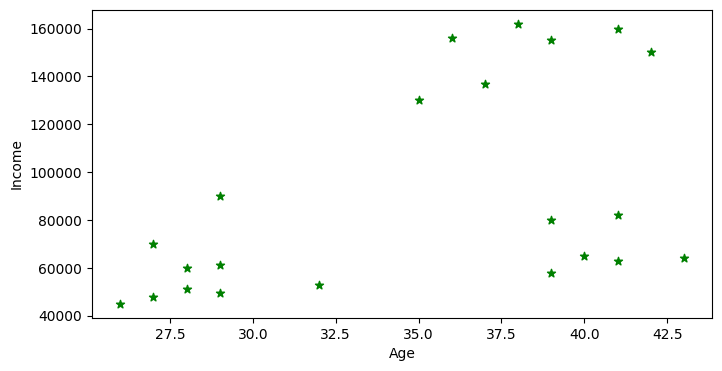

In [9]:
plt.figure(figsize=(8,4))
plt.scatter(df.Age,df.Income, color="Green", marker ="*")
plt.xlabel('Age')
plt.ylabel('Income')

In [10]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)

In [11]:
y_pred = model.fit_predict(df[['Age','Income']])

In [12]:
y_pred

array([0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [13]:
df['Cluster'] =y_pred

In [14]:
df

,Name,Age,Income,Cluster
0,Rob,27,70000,0
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1
5,Gautam,39,155000,1
6,David,41,160000,1
7,Andrea,38,162000,1
8,Brad,36,156000,1
9,Angelina,35,130000,1


In [17]:
df1 =df[df.Cluster == 0]
df2 =df[df.Cluster == 1]
df3 =df[df.Cluster == 2]

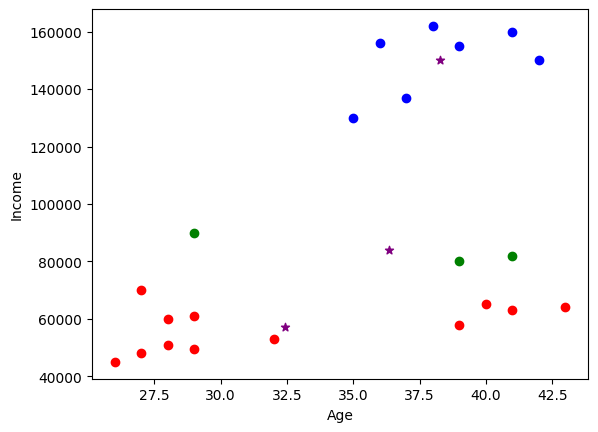

In [22]:
plt.scatter(df1.Age,df1.Income, color ='red')
plt.scatter(df2.Age,df2.Income, color ='blue')
plt.scatter(df3.Age,df3.Income, color ='green')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],color ='purple', marker="*",label ="Centroid")
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [23]:
sse =[]
k_range = range(1,10)
for k in range(1,10):
    km = KMeans(n_clusters =k)
    km.fit(df[['Age','Income']])
    sse.append(km.inertia_)

In [24]:
sse

[39748148458.545456,
 3318233941.161905,
 1577046058.883117,
 1058800432.7238096,
 296500418.0952381,
 238167028.08333334,
 173633694.45000002,
 157800323.62857145,
 100633576.86666667]

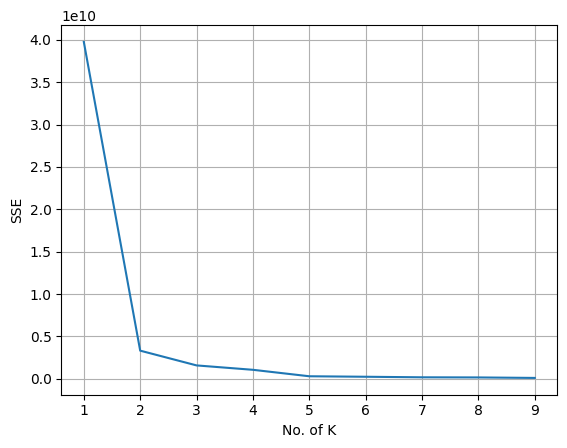

In [25]:
plt.xlabel('No. of K')
plt.ylabel('SSE')
plt.plot(k_range, sse)
plt.grid(True)
plt.show()

In [26]:
from sklearn.metrics import silhouette_score

In [28]:
silhouette_score(df[['Age','Income']], df['Cluster'])

0.6817458573419205

In [29]:
model2 = KMeans(n_clusters=2)

In [30]:
y_pred2 = model2.fit_predict(df[['Age','Income']])

In [31]:
y_pred2

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [32]:
df['Cluster2'] = y_pred2

In [33]:
df

,Name,Age,Income,Cluster,Cluster2
0,Rob,27,70000,0,0
1,Michael,29,90000,2,0
2,Mohan,29,61000,0,0
3,Ismail,28,60000,0,0
4,Kory,42,150000,1,1
5,Gautam,39,155000,1,1
6,David,41,160000,1,1
7,Andrea,38,162000,1,1
8,Brad,36,156000,1,1
9,Angelina,35,130000,1,1


In [34]:
df11 =df[df.Cluster2==0]
df21=df[df.Cluster2 ==1]

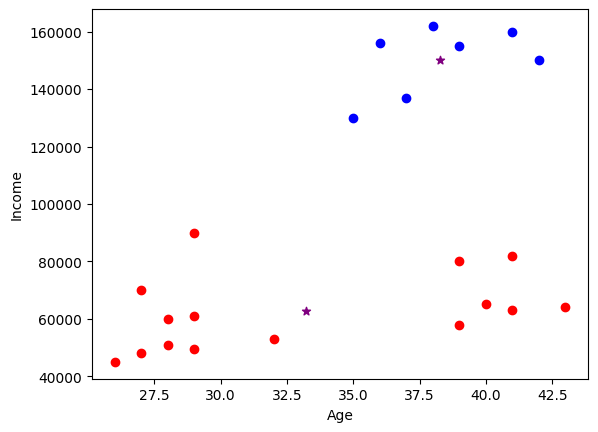

In [36]:
plt.scatter(df11.Age, df11.Income, color ='red')
plt.scatter(df21.Age, df21.Income, color ='blue')
plt.scatter( model2.cluster_centers_[:,0],model2.cluster_centers_[:,1], color='purple',marker ="*", label="Centroid")
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [37]:
silhouette_score(df[['Age','Income']], df['Cluster2'])

0.8191238627089519